<a href="https://colab.research.google.com/github/MInesGomes/AI-Project2026/blob/main/InesGomes_AI_BusinessProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Goal: Predict whether a ticket will be solved quickly or not.

We'll use this data set for training
https://www.kaggle.com/datasets/akashbommidi/customer-support-data

##1. Load the Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akashbommidi/customer-support-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-support-data' dataset.
Path to dataset files: /kaggle/input/customer-support-data


##2. Explore the Data

* View attributes (columns),
* Remove irrelevant columns,
* Normalize or discretize numerical data if needed.
* New columns dates

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import os

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------

df = pd.read_csv(os.path.join(path, 'Customer_support_data.csv'))


print("Initial rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())

Initial rows:
                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks  \
0                Life Insurance              NaN   
1  Product Specific Information              NaN   
2             Installation/demo              NaN   
3        Reverse Pickup Enquiry              NaN   
4                    Not Needed              NaN   

                               Order_id order_date_time Issue_reported at  \
0  c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaN  01-08-2023 11:13   
1  d406b0c7-ce17-4654-b9de-f08d421254bd             NaN  01-08-2023 12:52   
2  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [ ]:
print("Descriptive statistics for df_local_csv:")
display(df.describe(include='all'))

Descriptive statistics for df_local_csv:


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09-08-2023 11:55,13-08-2023 10:40,28-08-2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


**Key Observations from customer support data:**

*   **Unique id, Order_id:** These columns have a count equal to their unique values, indicating each entry is distinct, as expected for identifiers.
*   **channel_name:** There are 3 unique channels, with 'Inbound' being the most frequent (68142 occurrences).
*   **category:** 12 unique categories exist, with 'Returns' being the most common (44097 occurrences).
*   **Sub-category:** There are 57 unique sub-categories, and 'Reverse Pickup Enquiry' is the most frequent.
*   **Customer Remarks:** This column has a significant number of missing values (only 28742 out of 85907 are non-null), suggesting it might require imputation or careful handling if used for analysis. 'Good' is the most frequent remark.
*   **order_date_time, Customer_City, Product_category, Item_price, connected_handling_time:** These columns also have many missing values, indicating that not all customer interactions are associated with order details, specific products, or cities. `Item_price` and `connected_handling_time` are numerical and show their mean, std, min, max, and quartiles.

Maybe we can drop everything except Item_price, as it could help us predict whether a ticket will be solved quickly or not.
*   **Issue_reported at, issue_responded, Survey_response_Date:** These appear to be date-time strings, with `issue_responded` having a top value of '28-08-2023 00:00' and `Survey_response_Date` '28-Aug-23', suggesting a concentration of responses on certain dates or a default value.
*   **Agent_name, Supervisor, Manager, Tenure Bucket, Agent Shift, CSAT Score:** These columns provide details about the support agents and their performance/attributes. There are many unique agent names (1371), and 'Wendy Taylor' is the most frequent. `CSAT Score` is an integer column, likely indicating satisfaction ratings.


In [ ]:
print(df.columns)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import os

# --------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------

df = pd.read_csv(os.path.join(path, 'Customer_support_data.csv'))

print("Initial rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())

Initial rows:
                              Unique id channel_name         category  \
0  7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1  b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2  200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3  eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4  ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   

                   Sub-category Customer Remarks  \
0                Life Insurance              NaN   
1  Product Specific Information              NaN   
2             Installation/demo              NaN   
3        Reverse Pickup Enquiry              NaN   
4                    Not Needed              NaN   

                               Order_id order_date_time Issue_reported at  \
0  c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaN  01-08-2023 11:13   
1  d406b0c7-ce17-4654-b9de-f08d421254bd             NaN  01-08-2023 12:52   
2  

###2.2 Remove irrelevant columns

In [ ]:
# --------------------------------------------------
# 2. DROP IRRELEVANT COLUMNS
# --------------------------------------------------
drop_cols = [
    "Unique id", "Order_id" , 'Customer Remarks', 'connected_handling_time',
    'Sub-category', 'Customer_City',  'Agent_name', 'Product_category'
    'Supervisor', 'Manager', 'Tenure Bucket'
]

dfDrop = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [ ]:
dfDrop.columns

Index(['channel_name', 'category', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Product_category',
       'Item_price', 'Supervisor', 'Agent Shift', 'CSAT Score'],
      dtype='object')

In [ ]:
# --------------------------------------------------
# 3. HANDLE DATETIME COLUMNS
# --------------------------------------------------

datetime_cols = [
    "order_date_time", "Issue_reported at",
    "issue_responded", "Survey_response_Date"
]
dfNorm = dfDrop.copy()
for col in datetime_cols:
    if col in dfDrop.columns:
        dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")

# Feature engineering
dfNorm["report_hour"] = dfNorm["Issue_reported at"].dt.hour
dfNorm["report_day"] = dfNorm["Issue_reported at"].dt.day
dfNorm["report_weekday"] = dfNorm["Issue_reported at"].dt.weekday

dfNorm["response_delay"] = (
    dfNorm["issue_responded"] - dfNorm["Issue_reported at"]
).dt.total_seconds() / 60  # minutes

dfNorm["survey_delay"] = (
    dfNorm["Survey_response_Date"] - dfNorm["issue_responded"]
).dt.total_seconds() / 60

# Drop raw datetime columns
dfNorm = dfNorm.drop(columns=datetime_cols)

/tmp/ipykernel_3486/431235451.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")
/tmp/ipykernel_3486/431235451.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dfNorm[col] = pd.to_datetime(dfNorm[col], errors="coerce")


In [ ]:
dfNorm.columns

Index(['channel_name', 'category', 'Product_category', 'Item_price',
       'Supervisor', 'Agent Shift', 'CSAT Score', 'report_hour', 'report_day',
       'report_weekday', 'response_delay', 'survey_delay'],
      dtype='object')

###2.3 HANDLE MISSING VALUES and ENCODE CATEGORICAL FEATURES

In [ ]:
# --------------------------------------------------
# 4. CREATE TARGET VARIABLE (High CSAT)
# --------------------------------------------------

dfClean = dfNorm.copy()
dfClean = dfClean.dropna(subset=["CSAT Score"])
dfClean["high_csat"] = (dfClean["CSAT Score"] >= 4).astype(int)

# Drop original CSAT column
dfClean = dfClean.drop(columns=["CSAT Score"])

# --------------------------------------------------
# 5. HANDLE MISSING VALUES
# --------------------------------------------------

# Numeric columns → fill with median
numeric_cols = dfClean.select_dtypes(include=[np.number]).columns
dfClean[numeric_cols] = dfClean[numeric_cols].fillna(dfClean[numeric_cols].median())

# Categorical columns → fill with "Unknown"
categorical_cols = dfClean.select_dtypes(include=["object"]).columns
dfClean[categorical_cols] = dfClean[categorical_cols].fillna("Unknown")

# --------------------------------------------------
# 6. ENCODE CATEGORICAL FEATURES
# --------------------------------------------------

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    dfClean[col] = le.fit_transform(dfClean[col].astype(str))
    label_encoders[col] = le

##3. Train Models

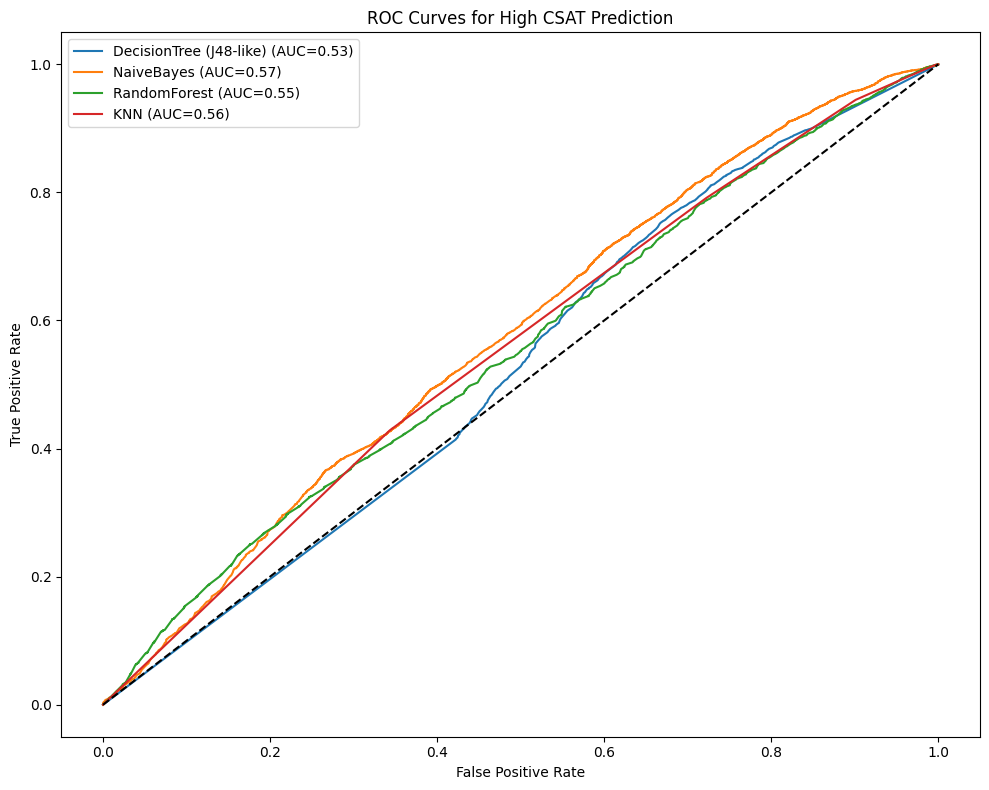

In [ ]:
# --------------------------------------------------
# 7. TRAIN-TEST SPLIT
# --------------------------------------------------

X = dfClean.drop(columns=["high_csat"])
y = dfClean["high_csat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --------------------------------------------------
# 8. TRAIN MODELS
# --------------------------------------------------

models = {
    "DecisionTree (J48-like)": DecisionTreeClassifier(random_state=42),
    "NaiveBayes": GaussianNB(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probability for ROC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({"model": name, "accuracy": acc, "roc_auc": roc_auc})

    # Plot ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ROC plot
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for High CSAT Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

##4. Accuracy Comparison


Model Comparison:
                     model  accuracy   roc_auc
0  DecisionTree (J48-like)  0.764599  0.527447
1               NaiveBayes  0.807357  0.574471
2             RandomForest  0.743375  0.553741
3                      KNN  0.796221  0.556080


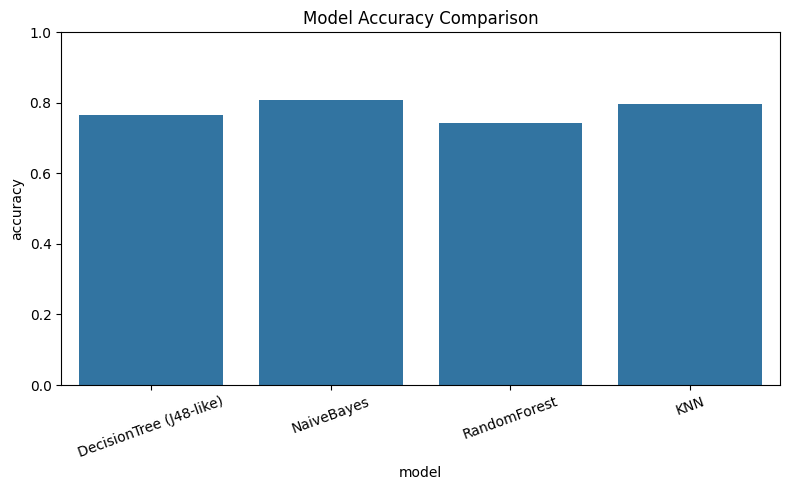


Best Model: NaiveBayes
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            471           4050
True_HighCSAT           915          20337


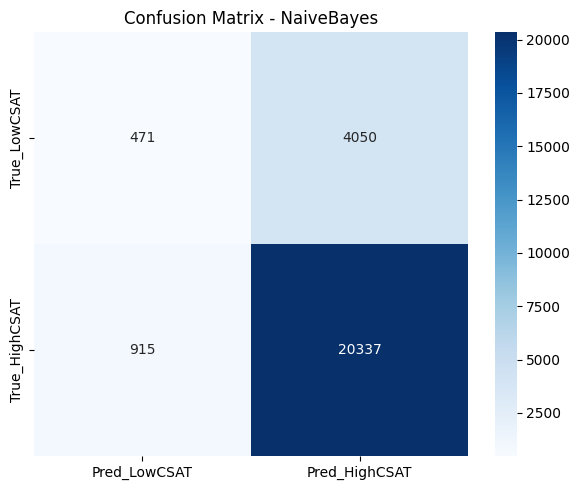

In [ ]:
# --------------------------------------------------
# 9. ACCURACY COMPARISON
# --------------------------------------------------

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="model", y="accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

# --------------------------------------------------
# 10. CONFUSION MATRIX FOR BEST MODEL
# --------------------------------------------------

best_model_name = results_df.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

print(f"\nBest Model: {best_model_name}")
print("Confusion Matrix:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Assuming y_test and y_pred_best are available from the previous step
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Low CSAT', 'High CSAT']))


Classification Report for NaiveBayes:
              precision    recall  f1-score   support

    Low CSAT       0.34      0.10      0.16      4521
   High CSAT       0.83      0.96      0.89     21252

    accuracy                           0.81     25773
   macro avg       0.59      0.53      0.53     25773
weighted avg       0.75      0.81      0.76     25773



### Addressing Class Imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original class distribution: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled class distribution: {Counter(y_train_res)}")

Original class distribution: Counter({1: 49584, 0: 10550})
Resampled class distribution: Counter({1: 49584, 0: 49584})


Now that the training data is balanced, let's retrain the models and evaluate their performance again.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:54:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


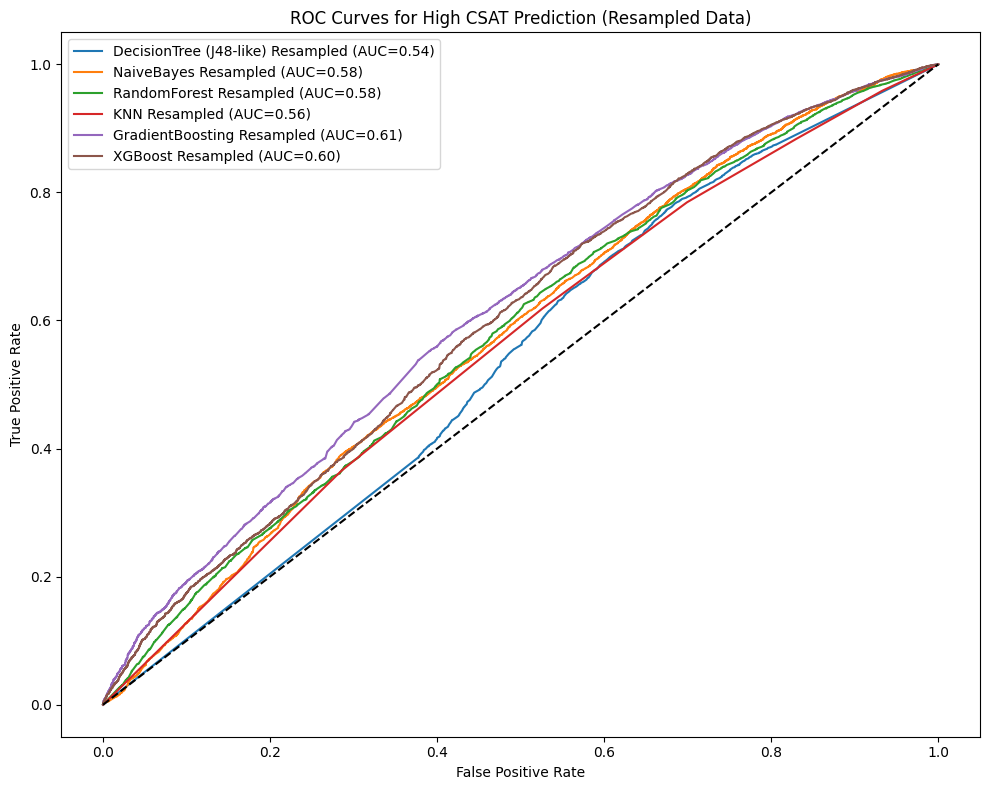


Model Comparison (Resampled Data):
                               model  accuracy   roc_auc
0  DecisionTree (J48-like) Resampled  0.661894  0.538967
1               NaiveBayes Resampled  0.803942  0.577067
2             RandomForest Resampled  0.685912  0.578549
3                      KNN Resampled  0.699686  0.561601
4         GradientBoosting Resampled  0.656967  0.611136
5                  XGBoost Resampled  0.711636  0.597418


/tmp/ipykernel_3486/167980733.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined_results_df, x="model", y="accuracy", palette="viridis")


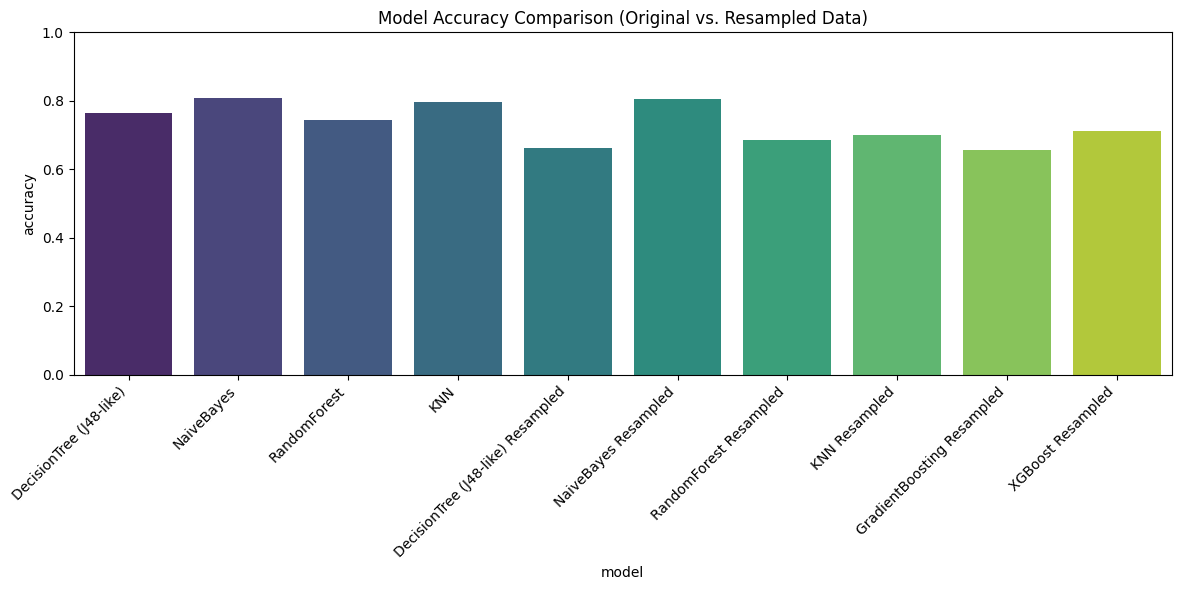


Best Model (Resampled Data): NaiveBayes Resampled
Confusion Matrix (Resampled Data):
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            537           3984
True_HighCSAT          1069          20183


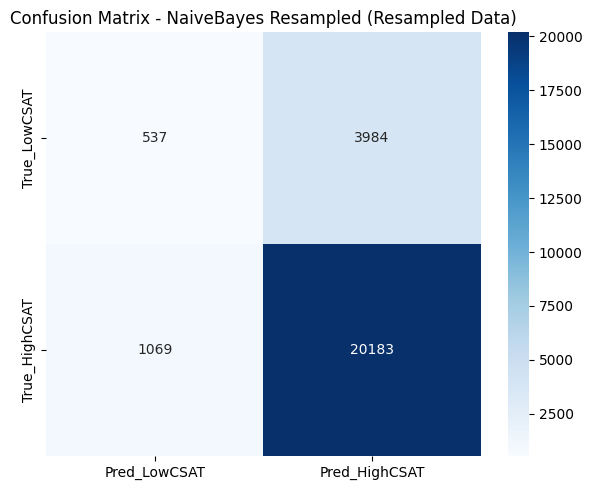


Classification Report for NaiveBayes Resampled (Resampled Data):
              precision    recall  f1-score   support

    Low CSAT       0.33      0.12      0.18      4521
   High CSAT       0.84      0.95      0.89     21252

    accuracy                           0.80     25773
   macro avg       0.58      0.53      0.53     25773
weighted avg       0.75      0.80      0.76     25773



In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

models_resampled = {
    "DecisionTree (J48-like) Resampled": DecisionTreeClassifier(random_state=42),
    "NaiveBayes Resampled": GaussianNB(),
    "RandomForest Resampled": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN Resampled": KNeighborsClassifier(n_neighbors=5),
    "GradientBoosting Resampled": GradientBoostingClassifier(random_state=42),
    "XGBoost Resampled": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) # Added XGBoost
}

results_resampled = []

plt.figure(figsize=(10, 8))

for name, model in models_resampled.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results_resampled.append({"model": name, "accuracy": acc, "roc_auc": roc_auc})

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for High CSAT Prediction (Resampled Data)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves_resampled.png", dpi=150)
plt.show()

results_df_resampled = pd.DataFrame(results_resampled)
print("\nModel Comparison (Resampled Data):")
print(results_df_resampled)

# Combine original and resampled results for a comprehensive comparison
combined_results_df = pd.concat([results_df, results_df_resampled])

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_results_df, x="model", y="accuracy", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison (Original vs. Resampled Data)")
plt.tight_layout()
plt.savefig("accuracy_comparison_combined.png", dpi=150)
plt.show()

best_model_name_resampled = results_df_resampled.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
best_model_resampled = models_resampled[best_model_name_resampled]

y_pred_best_resampled = best_model_resampled.predict(X_test)
cm_resampled = confusion_matrix(y_test, y_pred_best_resampled)

cm_df_resampled = pd.DataFrame(
    cm_resampled,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

print(f"\nBest Model (Resampled Data): {best_model_name_resampled}")
print("Confusion Matrix (Resampled Data):")
print(cm_df_resampled)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df_resampled, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name_resampled} (Resampled Data)")
plt.tight_layout()
plt.savefig("confusion_matrix_resampled.png", dpi=150)
plt.show()

print(f"\nClassification Report for {best_model_name_resampled} (Resampled Data):")
print(classification_report(y_test, y_pred_best_resampled, target_names=['Low CSAT', 'High CSAT']))

In [ ]:
from sklearn.metrics import classification_report

print(f"\nClassification Report for {best_model_name_resampled} (Resampled Data):")
print(classification_report(y_test, y_pred_best_resampled, target_names=['Low CSAT', 'High CSAT']))


Classification Report for NaiveBayes Resampled (Resampled Data):
              precision    recall  f1-score   support

    Low CSAT       0.33      0.12      0.18      4521
   High CSAT       0.84      0.95      0.89     21252

    accuracy                           0.80     25773
   macro avg       0.58      0.53      0.53     25773
weighted avg       0.75      0.80      0.76     25773



### Classification Report for GradientBoosting Resampled

In [ ]:
from sklearn.metrics import classification_report

gradient_boosting_model_name = "GradientBoosting Resampled"
gradient_boosting_model = models_resampled[gradient_boosting_model_name]
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print(f"\nClassification Report for {gradient_boosting_model_name}:")
print(classification_report(y_test, y_pred_gradient_boosting, target_names=['Low CSAT', 'High CSAT']))


Classification Report for GradientBoosting Resampled:
              precision    recall  f1-score   support

    Low CSAT       0.24      0.45      0.31      4521
   High CSAT       0.86      0.70      0.77     21252

    accuracy                           0.66     25773
   macro avg       0.55      0.57      0.54     25773
weighted avg       0.75      0.66      0.69     25773



### Classification Report for XGBoost Resampled

In [ ]:
from sklearn.metrics import classification_report

xgb_model_name = "XGBoost Resampled"
xgb_model = models_resampled[xgb_model_name]
y_pred_xgb = xgb_model.predict(X_test)

print(f"\nClassification Report for {xgb_model_name}:")
print(classification_report(y_test, y_pred_xgb, target_names=['Low CSAT', 'High CSAT']))


Classification Report for XGBoost Resampled:
              precision    recall  f1-score   support

    Low CSAT       0.26      0.34      0.29      4521
   High CSAT       0.85      0.79      0.82     21252

    accuracy                           0.71     25773
   macro avg       0.55      0.56      0.56     25773
weighted avg       0.75      0.71      0.73     25773



### Threshold Tuning for GradientBoosting Resampled

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gradient_boosting_model_name = "GradientBoosting Resampled"
gradient_boosting_model = models_resampled[gradient_boosting_model_name]

# Get predicted probabilities for the positive class (High CSAT, which is 1)
y_proba_gradient_boosting = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Define a range of thresholds to explore
# We'll try a wider range, or more granular steps, focusing on improving 'Low CSAT' recall
thresholds = np.arange(0.1, 0.9, 0.05) # From 0.1 to 0.85

print(f"\nEvaluating {gradient_boosting_model_name} with different classification thresholds:")

for threshold in thresholds:
    # Classify based on the new threshold: if proba of High CSAT > threshold, then High CSAT (1), else Low CSAT (0)
    y_pred_threshold = (y_proba_gradient_boosting >= threshold).astype(int)

    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    cm_df_threshold = pd.DataFrame(
        cm_threshold,
        index=["True_LowCSAT", "True_HighCSAT"],
        columns=["Pred_LowCSAT", "Pred_HighCSAT"]
    )

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print("Confusion Matrix:")
    print(cm_df_threshold)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_threshold, target_names=['Low CSAT', 'High CSAT']))

# Optional: Visualize the confusion matrix for a chosen best threshold
# After reviewing the output, we can select a threshold and visualize it


Evaluating GradientBoosting Resampled with different classification thresholds:

--- Threshold: 0.10 ---
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT              2           4519
True_HighCSAT             4          21248

Classification Report:
              precision    recall  f1-score   support

    Low CSAT       0.33      0.00      0.00      4521
   High CSAT       0.82      1.00      0.90     21252

    accuracy                           0.82     25773
   macro avg       0.58      0.50      0.45     25773
weighted avg       0.74      0.82      0.75     25773


--- Threshold: 0.15 ---
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT             23           4498
True_HighCSAT            18          21234

Classification Report:
              precision    recall  f1-score   support

    Low CSAT       0.56      0.01      0.01      4521
   High CSAT       0.83      1.00      0.90     21252

    accuracy                        


Evaluating NaiveBayes Resampled with different classification thresholds:

--- Threshold: 0.10 ---
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            443           4078
True_HighCSAT           878          20374

Classification Report:
              precision    recall  f1-score   support

    Low CSAT       0.34      0.10      0.15      4521
   High CSAT       0.83      0.96      0.89     21252

    accuracy                           0.81     25773
   macro avg       0.58      0.53      0.52     25773
weighted avg       0.75      0.81      0.76     25773


--- Threshold: 0.15 ---
Confusion Matrix:
               Pred_LowCSAT  Pred_HighCSAT
True_LowCSAT            466           4055
True_HighCSAT           904          20348

Classification Report:
              precision    recall  f1-score   support

    Low CSAT       0.34      0.10      0.16      4521
   High CSAT       0.83      0.96      0.89     21252

    accuracy                           0.8

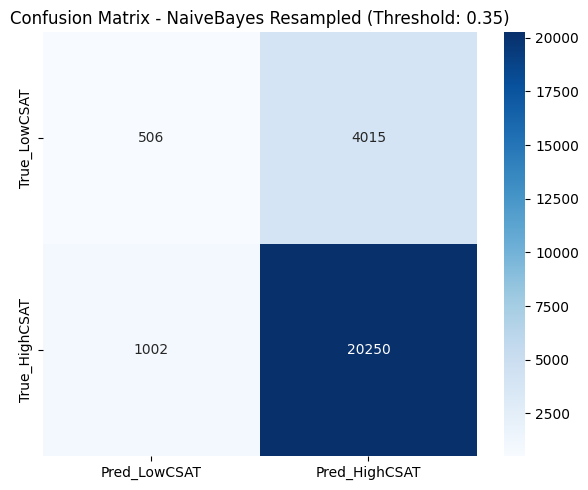

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

best_model_name_resampled = "NaiveBayes Resampled"
best_model_resampled = models_resampled[best_model_name_resampled]

# Get predicted probabilities for the positive class (High CSAT, which is 1)
y_proba_resampled = best_model_resampled.predict_proba(X_test)[:, 1]

# Define a range of thresholds to explore
thresholds = np.arange(0.1, 0.6, 0.05) # From 0.1 to 0.55

print(f"\nEvaluating {best_model_name_resampled} with different classification thresholds:")

for threshold in thresholds:
    # Classify based on the new threshold: if proba of High CSAT > threshold, then High CSAT (1), else Low CSAT (0)
    y_pred_threshold = (y_proba_resampled >= threshold).astype(int)

    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    cm_df_threshold = pd.DataFrame(
        cm_threshold,
        index=["True_LowCSAT", "True_HighCSAT"],
        columns=["Pred_LowCSAT", "Pred_HighCSAT"]
    )

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print("Confusion Matrix:")
    print(cm_df_threshold)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_threshold, target_names=['Low CSAT', 'High CSAT']))

# Optional: Visualize the confusion matrix for a chosen best threshold
# After reviewing the output, you can choose a threshold and visualize it
# For example, let's pick a threshold that seems to offer a good balance (e.g., 0.35 from inspection)
selected_threshold = 0.35
y_pred_optimized = (y_proba_resampled >= selected_threshold).astype(int)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
cm_df_optimized = pd.DataFrame(
    cm_optimized,
    index=["True_LowCSAT", "True_HighCSAT"],
    columns=["Pred_LowCSAT", "Pred_HighCSAT"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df_optimized, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name_resampled} (Threshold: {selected_threshold:.2f})")
plt.tight_layout()
plt.show()